In [2]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'figure.dpi': 600,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 8,
    'lines.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.4
})

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from src.config import EnvConfig
from src.utils.data_processing import (
    load_and_cache_entire_fleet,
    downsample_block_mean,
    generate_demand_grid
)

In [3]:
print("Loading and stitching the 11-day operational dataset...")
env = EnvConfig()
fleet_cache = load_and_cache_entire_fleet(env)

exclude_days = [1, 2, 3]
valid_days = sorted([d for d in fleet_cache.keys() if d not in exclude_days])

# 1. Stitch into continuous timeline for macroscopic analysis
t_raw_list, pd_raw_list = [], []
for i, day in enumerate(valid_days):
    # Shift time by 86400s (24h) per day so the x-axis is continuous
    t_raw_list.append(fleet_cache[day]['t'] + i * 86400.0)
    pd_raw_list.append(fleet_cache[day]['Pd'])

t_raw = np.concatenate(t_raw_list)
pd_raw = np.concatenate(pd_raw_list)

# 2. Block-Average downsampling (delta_t = 300s baseline)
DT_BASELINE = 300
ds_data = downsample_block_mean(t_raw, pd_raw, DT_BASELINE, align='t0')
t_avg = ds_data['t']
pd_avg = ds_data['Pd']

print(f"Raw 1Hz data points: {len(pd_raw):,}")
print(f"Block-averaged data points (delta_t={DT_BASELINE}s): {len(pd_avg):,}")

Loading and stitching the 11-day operational dataset...
Loading fleet data from binary cache (fleet_data_cache_scale_0.75.npz)...
 -> Cache instantly loaded in 0.120 seconds.
Raw 1Hz data points: 950,399
Block-averaged data points (delta_t=300s): 3,168


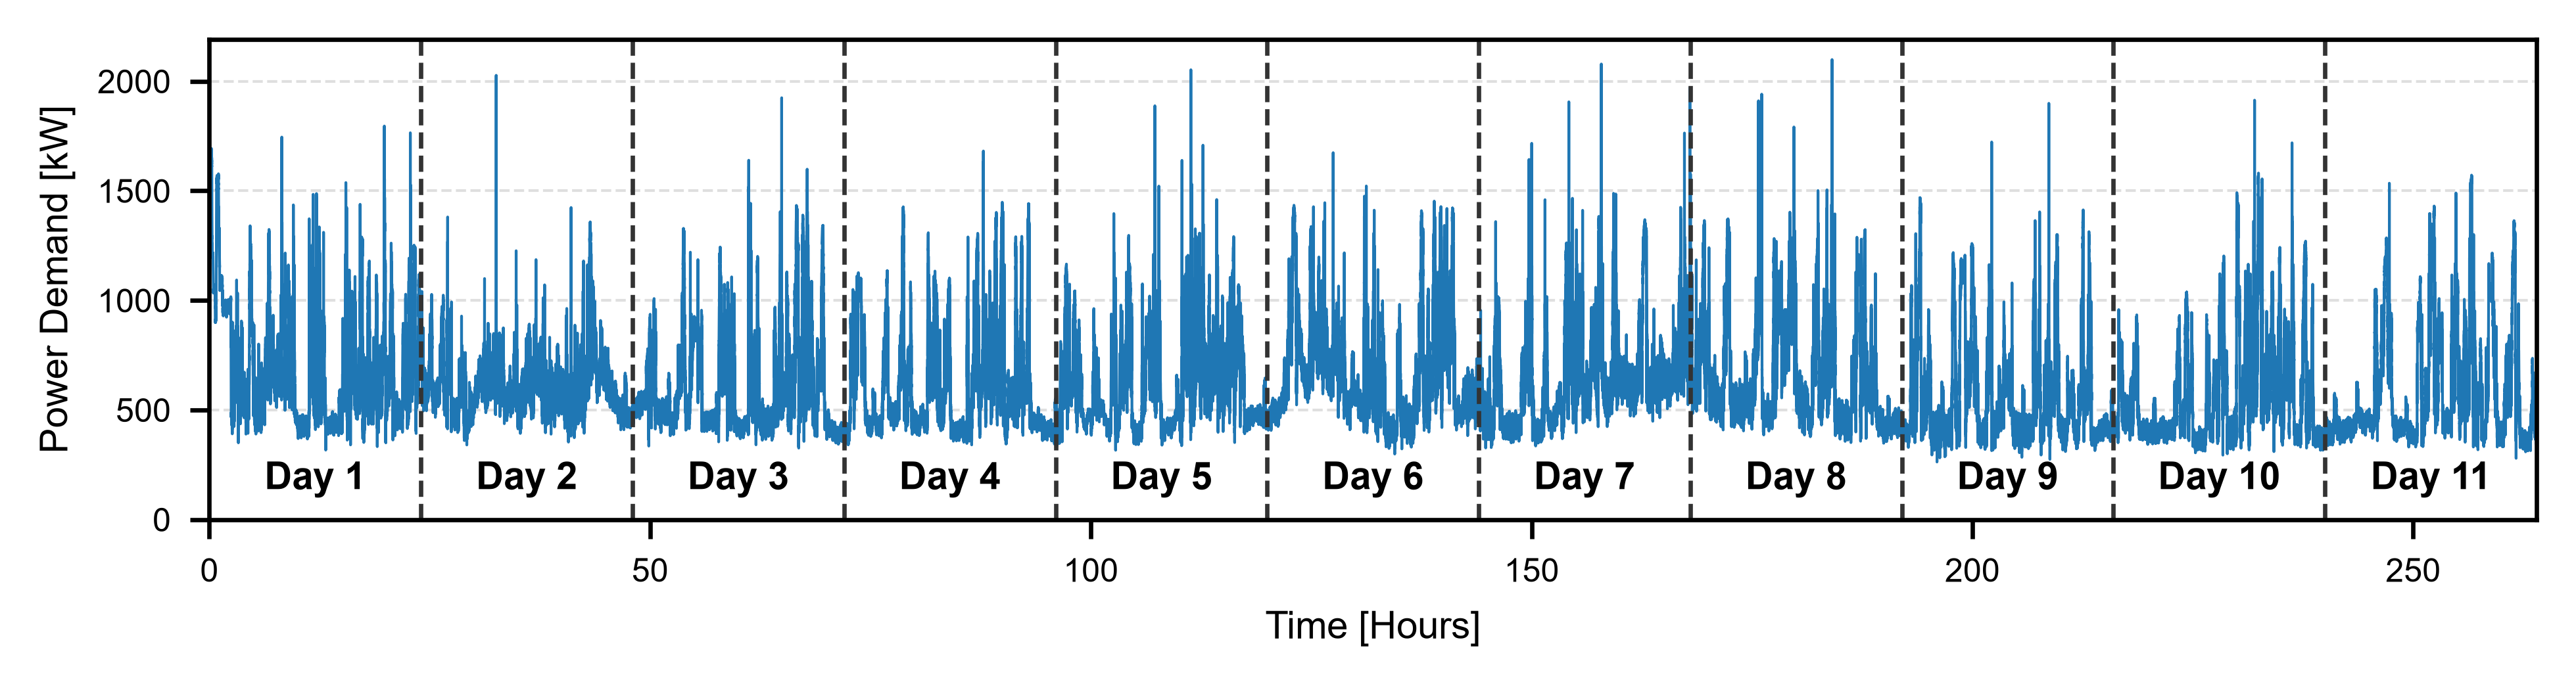

In [4]:
n=1

os.makedirs('figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(6.54, 1.75)) # Elsevier full-width figure size

# 1. Plot the raw data (light and thin so it doesn't overpower)
ax.plot(t_raw[::n] / 3600.0, pd_raw[::n], color='#1f77b4', alpha=1, lw=0.5)

# 2. Add the Day Delimiters
current_bottom, current_top = ax.get_ylim()
ax.set_ylim(bottom=0, top=current_top)
y_bottom_pos = current_bottom + (current_top - current_bottom) * 0.5


for i in range(1, len(valid_days)):
    ax.axvline(i * 24.0, color='#333333', linestyle='--', alpha=1, lw=0.8)
    ax.text(i * 24.0 - 12.0, 100, f'Day {i}', ha='center', va='bottom', fontsize=7, fontweight="bold")
ax.text(len(valid_days) * 24.0 - 12.0, 100, f'Day {len(valid_days)}', ha='center', va='bottom', fontsize=7, fontweight="bold")

ax.set_xlim(0, len(valid_days) * 24.0)
ax.set_xlabel("Time [Hours]")
ax.set_ylabel("Power Demand [kW]")

current_bottom, current_top = ax.get_ylim()
ax.set_ylim(bottom=current_bottom, top=current_top)

ax.grid(True, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('figures/dataset.pdf', dpi=300, bbox_inches='tight')
plt.show()

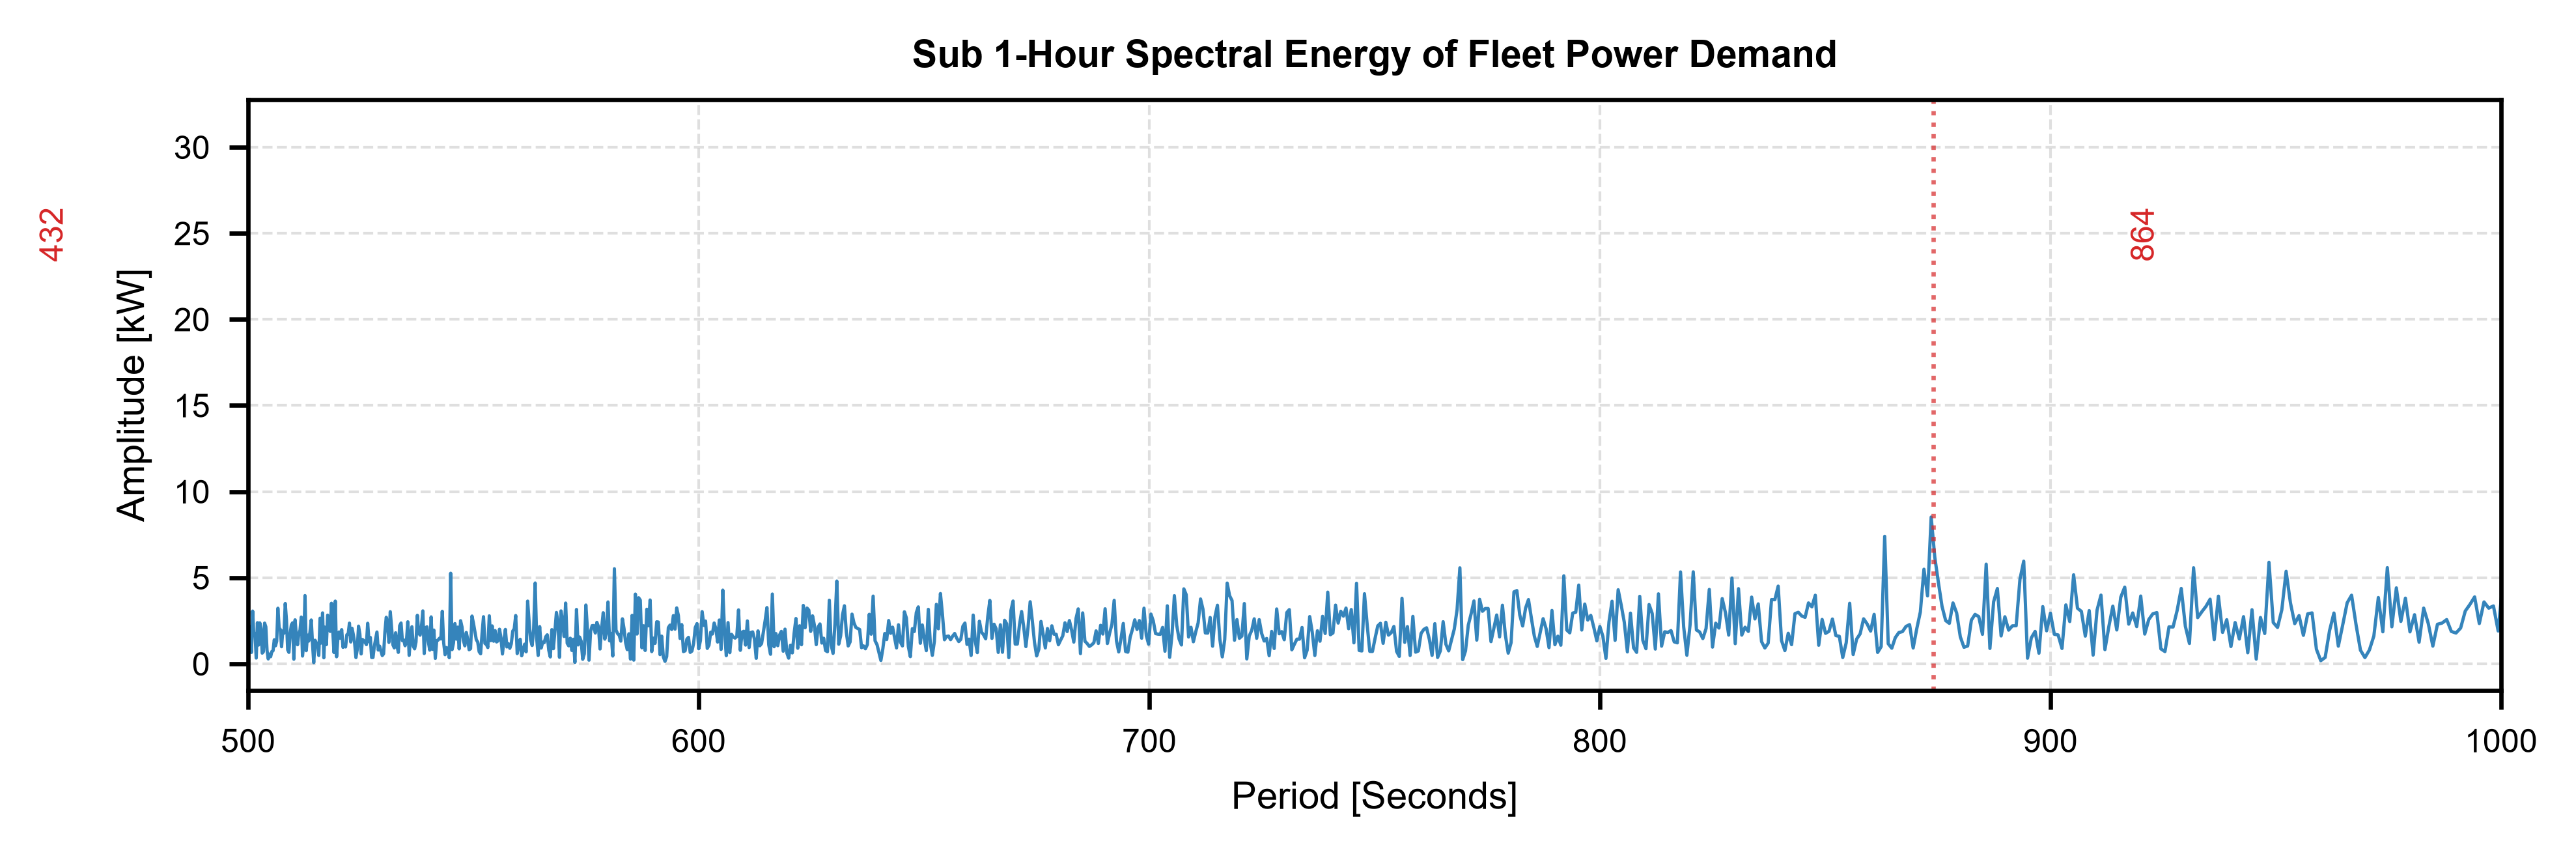

In [12]:
# ==========================================
# FFT Spectrum: Sub 1-Hour Periods (Seconds)
# ==========================================

# 1. Estimate sampling rate and duration
dt = np.mean(np.diff(t_raw))  # Sampling interval (s)
N = len(pd_raw)

# 2. Subtract DC offset
pd_centered = pd_raw - np.mean(pd_raw)

# 3. Compute Real FFT
fft_vals = np.fft.rfft(pd_centered)
freqs_hz = np.fft.rfftfreq(N, d=dt)
amplitudes = (2.0 / N) * np.abs(fft_vals)

# 4. Filter out DC (0 Hz) to avoid division by zero
valid_idx = freqs_hz > 0
f_valid = freqs_hz[valid_idx]
amp_valid = amplitudes[valid_idx]

# Convert frequencies to Period in Seconds: T [s] = 1 / f [Hz]
periods_sec = 1.0 / f_valid

# Mask for sub 1-hour dynamics (Period < 3,600 seconds)
sub_1h_mask = periods_sec < 7200.0

p_plot = periods_sec[sub_1h_mask]
amp_plot = amp_valid[sub_1h_mask]

# Sort periods ascending (e.g., 2s -> 3600s) for clean plotting
sort_idx = np.argsort(p_plot)
p_plot = p_plot[sort_idx]
amp_plot = amp_plot[sort_idx]

# 5. Plotting
fig, ax = plt.subplots(figsize=(6.54, 2.2))

ax.plot(p_plot, amp_plot, color='#1f77b4', lw=0.6, alpha=0.9)

# Highlight key sub-hour periods in seconds
key_periods_sec = {
    '432':432,
    '864': 874,
}

y_max = amp_plot.max()
for label, p_val in key_periods_sec.items():
    if p_plot.min() <= p_val <= p_plot.max():
        ax.axvline(p_val, color='#d62728', linestyle=':', lw=0.8, alpha=0.7)
        ax.text(
            p_val * 1.05, y_max * 0.85, label, 
            rotation=90, fontsize=6, color='#d62728', va='top'
        )

# Use logarithmic scale to view both fast (seconds) and slower (hundreds of seconds) dynamics
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlim(left=500, right=1000)

ax.set_xlabel("Period [Seconds]")
ax.set_ylabel("Amplitude [kW]")
ax.set_title("Sub 1-Hour Spectral Energy of Fleet Power Demand", fontsize=7, fontweight='bold')

ax.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('figures/fft_sub_1h_period_seconds.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
print("\n--- RUNNING MSQE GRID ANALYSIS ---")
dp_test_vals = [80]
nd_test_vals = list(range(2, 55,1))  # Test 3 to 25 states

msqe_results = {dp: [] for dp in dp_test_vals}

for dp in dp_test_vals:
    print(f"Evaluating delta_P = {dp} kW...")
    for nd in nd_test_vals:
        # The DP algorithm guarantees the mathematical absolute minimum error for this subset
        levels, edges = generate_demand_grid(pd_avg, delta_P=dp, N_d=nd, method='geometric')
        
        # Digitize the averaged data onto the Voronoi edges to find the closest node
        bin_indices = np.digitize(pd_avg, edges) - 1
        bin_indices = np.clip(bin_indices, 0, len(levels) - 1)
        pd_quantized = levels[bin_indices]
        
        # Calculate Mean Squared Quantization Error
        error = np.mean((pd_avg - pd_quantized)**2)
        msqe_results[dp].append(error)
        
print("MSQE Analysis Complete.\n")

# --- NEW: Markdown Table Generation ---
import pandas as pd
from src.utils.evaluation import print_markdown_table

# Convert the results dictionary to a Pandas DataFrame
df_msqe = pd.DataFrame(msqe_results, index=nd_test_vals)
df_msqe.index.name = "N_d (States)"

# Format the column names to look clean in the table
df_msqe.columns = [f"delta_P = {int(dp)} kW (MSQE)" for dp in dp_test_vals]

# Print using your project's custom Markdown formatter
print("\n--- MSQE RESULTS TABLE ---")
print_markdown_table(df_msqe)


--- RUNNING MSQE GRID ANALYSIS ---
Evaluating delta_P = 80 kW...
MSQE Analysis Complete.


--- MSQE RESULTS TABLE ---
| N_d (States) | delta_P = 80 kW (MSQE) |
|--------------|------------------------|
| 2            | 16107.31               |
| 3            | 7285.57                |
| 4            | 4501.28                |
| 5            | 3072.89                |
| 6            | 2299.70                |
| 7            | 1724.87                |
| 8            | 1311.58                |
| 9            | 1022.78                |
| 10           | 835.98                 |
| 11           | 717.33                 |
| 12           | 638.13                 |
| 13           | 591.19                 |
| 14           | 555.94                 |
| 15           | 546.66                 |
| 16           | 540.58                 |
| 17           | 536.91                 |
| 18           | 535.70                 |
| 19           | 535.70                 |
| 20           | 535.70                 |

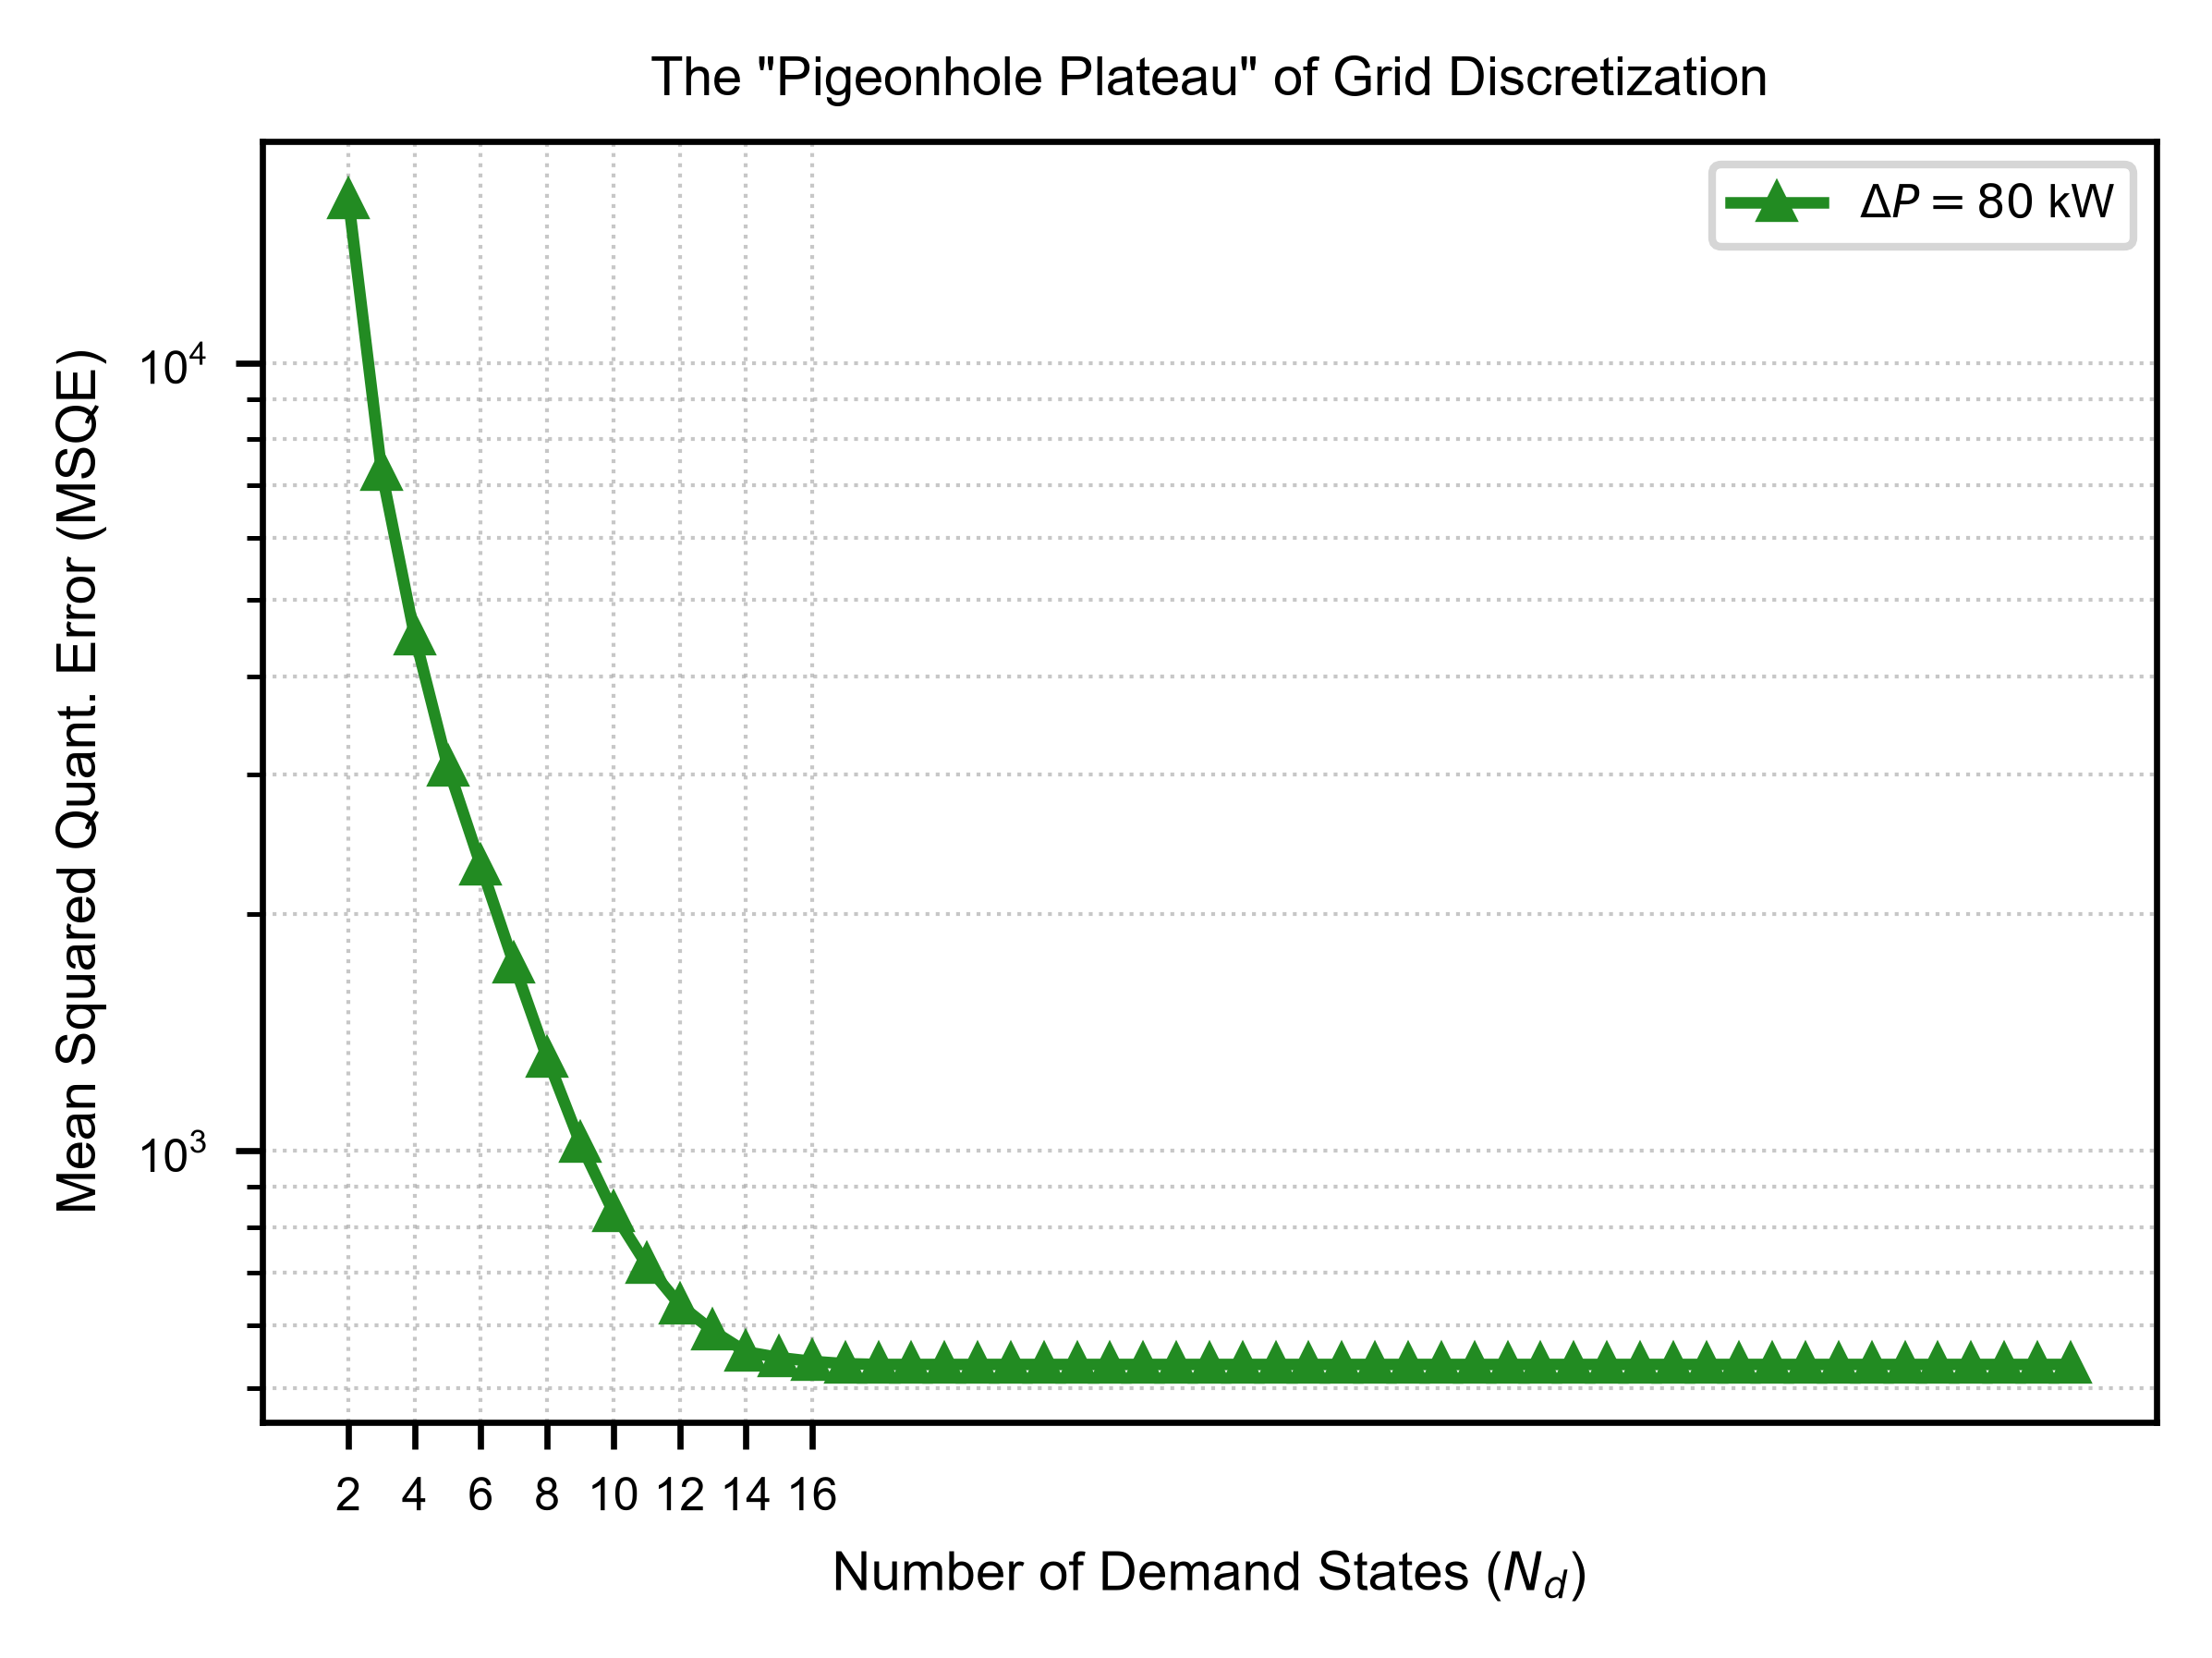

In [7]:
fig, ax = plt.subplots(figsize=(4.0, 3.0)) # Half-width column size for Elsevier

colors = ['forestgreen', 'navy', 'crimson', 'darkorange']
markers = ['^', 'o', 's', 'd']

for idx, dp in enumerate(dp_test_vals):
    ax.plot(nd_test_vals, msqe_results[dp], 
            color=colors[idx], marker=markers[idx], markersize=4, lw=1.5,
            label=f'$\\Delta P = {int(dp)}$ kW')

ax.set_xlabel('Number of Demand States ($N_d$)')
ax.set_ylabel('Mean Squared Quant. Error (MSQE)')
ax.set_title('The "Pigeonhole Plateau" of Grid Discretization')

# Apply Logarithmic Scale to the Y-axis
ax.set_yscale('log')

ax.set_xticks(np.arange(2, 17, 2))

# Use 'both' to draw grid lines for both major and minor log ticks
ax.grid(True, which='both', linestyle=':', alpha=0.7) 
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('figures/06_msqe_plateau.png', dpi=300, bbox_inches='tight')
plt.show()